Name: Adam Gebben


### Data Project 

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("Mental_Health_Care_in_the_Last_4_Weeks.csv")

print("An intial look at the format of the dataset:\n")
df.head(5)


An intial look at the format of the dataset:



,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Confidence Interval,Quartile Range,Suppression Flag
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2,15,"Sep 16 - Sep 28, 2020",09/16/2020,09/28/2020,6.9,6.5,7.3,6.5 - 7.3,NaN,NaN
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2,15,"Sep 16 - Sep 28, 2020",09/16/2020,09/28/2020,11.0,10.4,11.6,10.4 - 11.6,NaN,NaN
2,Needed Counseling or Therapy But Did Not Get I...,By Sex,United States,Female,-1,1,"Dec 22, 2020 - Jan 5, 2021",12/22/2020,01/05/2021,NaN,NaN,NaN,NaN,NaN,NaN
3,Took Prescription Medication for Mental Health...,By Age,United States,50 - 59 years,-1,1,"Mar 30 - Apr 13, 2021",03/30/2021,04/13/2021,NaN,NaN,NaN,NaN,NaN,NaN
4,Took Prescription Medication for Mental Health...,By Age,United States,60 - 69 years,-1,1,"Mar 30 - Apr 13, 2021",03/30/2021,04/13/2021,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# basic cleaning
df = df.drop(columns=['Confidence Interval', 'Time Period Label', 'Time Period', 'Phase'])
df['Time Period Start Date'] = pd.to_datetime(df['Time Period Start Date'])
df['Time Period Length'] = pd.to_datetime(df['Time Period End Date']) - pd.to_datetime(df['Time Period Start Date'])
df = df.drop(columns=['Time Period End Date'])

groups =  df['Group'].unique()
print("Unique groups: ", groups, "\n")

Indicator =  df['Indicator'].unique()
print("Unique Indicator: ", Indicator, "\n")


Unique groups:  ['By Sex' 'By Age' 'National Estimate'
 'By Presence of Symptoms of Anxiety/Depression'
 'By Race/Hispanic ethnicity' 'By Education' 'By State'
 'By Sexual orientation' 'By Disability status' 'By Gender identity'] 

Unique Indicator:  ['Received Counseling or Therapy, Last 4 Weeks'
 'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks'
 'Took Prescription Medication for Mental Health, Last 4 Weeks'
 'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks'] 



In [3]:
for group in groups:
  print(f"{'Num rows for '+ group:<60}: {df.loc[df['Group'] == group].shape[0]}")
  
print("\n",df.loc[df['Group'] == 'By State']["Subgroup"].unique())
print("\nThe state group contains all states and DC.\n")

df.head(5)

Num rows for By Sex                                         : 304
Num rows for By Age                                         : 1064
Num rows for National Estimate                              : 152
Num rows for By Presence of Symptoms of Anxiety/Depression  : 304
Num rows for By Race/Hispanic ethnicity                     : 760
Num rows for By Education                                   : 608
Num rows for By State                                       : 6732
Num rows for By Sexual orientation                          : 156
Num rows for By Disability status                           : 168
Num rows for By Gender identity                             : 156

 ['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hamp

,Indicator,Group,State,Subgroup,Time Period Start Date,Value,LowCI,HighCI,Quartile Range,Suppression Flag,Time Period Length
0,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Male,2020-09-16,6.9,6.5,7.3,NaN,NaN,12 days
1,"Received Counseling or Therapy, Last 4 Weeks",By Sex,United States,Female,2020-09-16,11.0,10.4,11.6,NaN,NaN,12 days
2,Needed Counseling or Therapy But Did Not Get I...,By Sex,United States,Female,2020-12-22,NaN,NaN,NaN,NaN,NaN,14 days
3,Took Prescription Medication for Mental Health...,By Age,United States,50 - 59 years,2021-03-30,NaN,NaN,NaN,NaN,NaN,14 days
4,Took Prescription Medication for Mental Health...,By Age,United States,60 - 69 years,2021-03-30,NaN,NaN,NaN,NaN,NaN,14 days


From initial exploration, the groups in this dataset that seem most worth exploring is 'By state'.

Other sub-datasets just have less entries, but are worth keeping aroud. Perhaps they will be valuable for looking at overall indicator trends over time.

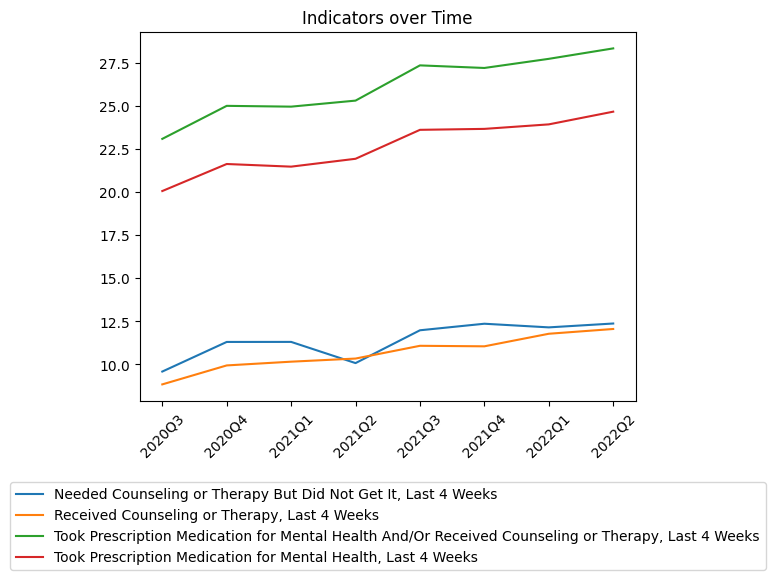

In [4]:
df['Quarter'] = pd.to_datetime(df['Time Period Start Date']).dt.to_period('Q')
quarterly = df.groupby(['Indicator', 'Quarter'])['Value'].mean().reset_index()

for indicator, group in quarterly.groupby('Indicator'):
    plt.plot(group['Quarter'].astype(str), group['Value'], label=indicator)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.xticks(rotation=45)
plt.title("Indicators over Time")
plt.show()

Looks like there was a general increase in all of the indicators from mid 2020 to mid 2022. Also, interestingly, people generally are much more likely to take medication than receive counceling. 

#### PCA and K-Means



In [5]:
#pivot for PCA
state_matrix = df.groupby(['State', 'Indicator'])['Value'].mean().unstack()
state_matrix = state_matrix.dropna()
state_matrix = state_matrix[state_matrix.index != 'United States']
print(state_matrix.shape)
state_matrix.head(5)


(51, 4)


Indicator,"Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks","Received Counseling or Therapy, Last 4 Weeks","Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks","Took Prescription Medication for Mental Health, Last 4 Weeks"
State,,,,
Alabama,11.363636,8.818182,27.196970,24.860606
Alaska,11.469697,10.442424,22.275758,18.096970
Arizona,11.493939,9.272727,22.996970,20.039394
Arkansas,11.318182,8.127273,28.706061,26.690909
California,11.651515,10.709091,21.278788,16.942424


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(state_matrix)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.cumsum()
print(explained)
X_scaled

[0.51855468 0.81021553 0.99905336 1.        ]


array([[ 4.44648027e-01, -7.04315758e-01,  4.54228444e-01,
         7.91518645e-01],
       [ 5.21403087e-01,  9.58640162e-02, -1.34996380e+00,
        -1.51312774e+00],
       [ 5.38947100e-01, -4.80384851e-01, -1.08555631e+00,
        -8.51264688e-01],
       [ 4.11753001e-01, -1.04469074e+00,  1.00748444e+00,
         1.41517743e+00],
       [ 6.52983189e-01,  2.27236815e-01, -1.71546826e+00,
        -1.90652840e+00],
       [ 1.64860596e+00,  9.34858481e-01,  1.99819562e-01,
        -3.65967286e-01],
       [-1.09045317e+00,  1.29911942e+00, -1.23729981e-02,
        -3.68032381e-01],
       [-9.23785037e-01,  5.10778349e-02, -4.66753926e-01,
        -3.44283785e-01],
       [ 2.11571533e+00,  3.85939612e+00,  7.09748281e-01,
        -9.54519454e-01],
       [-4.04043633e-01, -9.80497209e-01, -1.33774328e+00,
        -9.55552002e-01],
       [ 1.05868850e+00, -5.22185287e-01, -7.18940895e-01,
        -5.64216437e-01],
       [-2.33785995e+00, -6.66993940e-01, -3.30968985e+00,
      

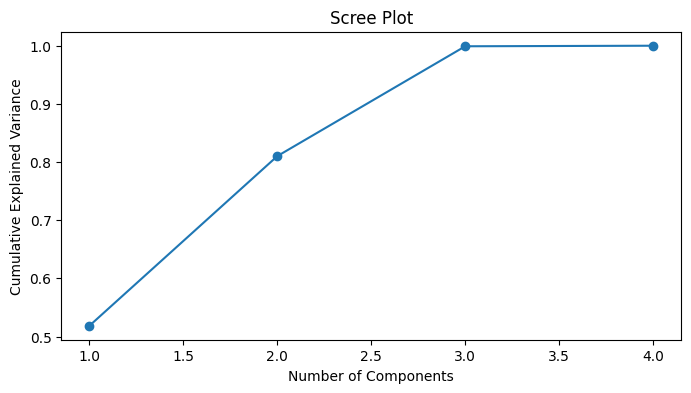

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(explained) + 1), explained, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.show()

In [8]:
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=state_matrix.columns,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)

print(loadings)

                                                         PC1       PC2
Indicator                                                             
Took Prescription Medication for Mental Health ...  0.680774 -0.099395
Took Prescription Medication for Mental Health,...  0.615443 -0.426647
Needed Counseling or Therapy But Did Not Get It...  0.329660  0.499319
Received Counseling or Therapy, Last 4 Weeks        0.221585  0.747512


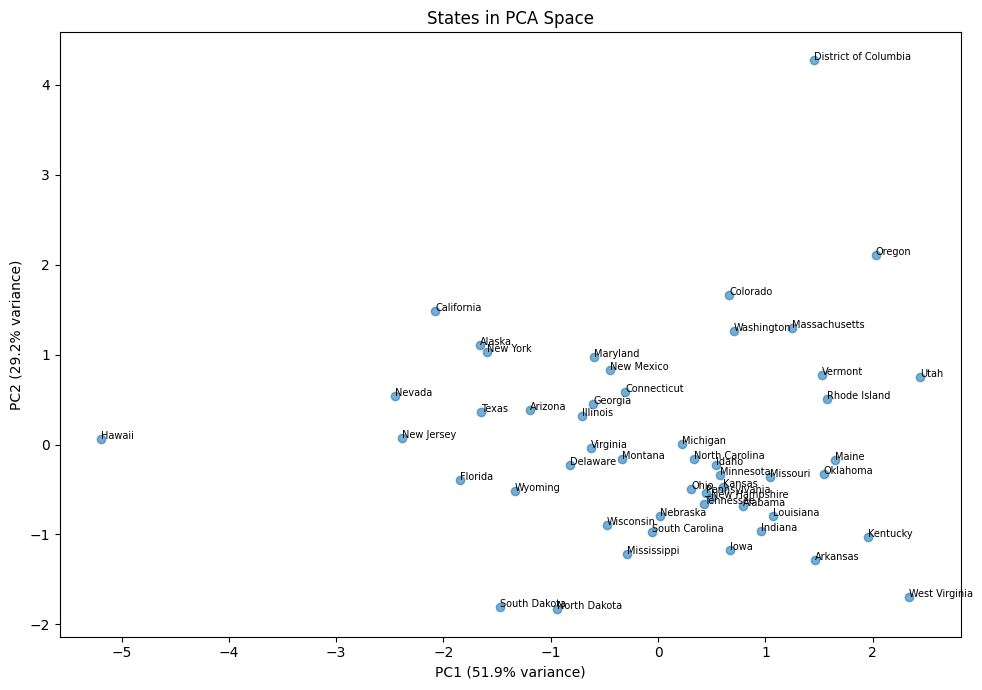

In [9]:
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)

for i, state in enumerate(state_matrix.index):
    plt.annotate(state, (X_pca[i, 0], X_pca[i, 1]), fontsize=7)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("States in PCA Space")
plt.tight_layout()
plt.show()

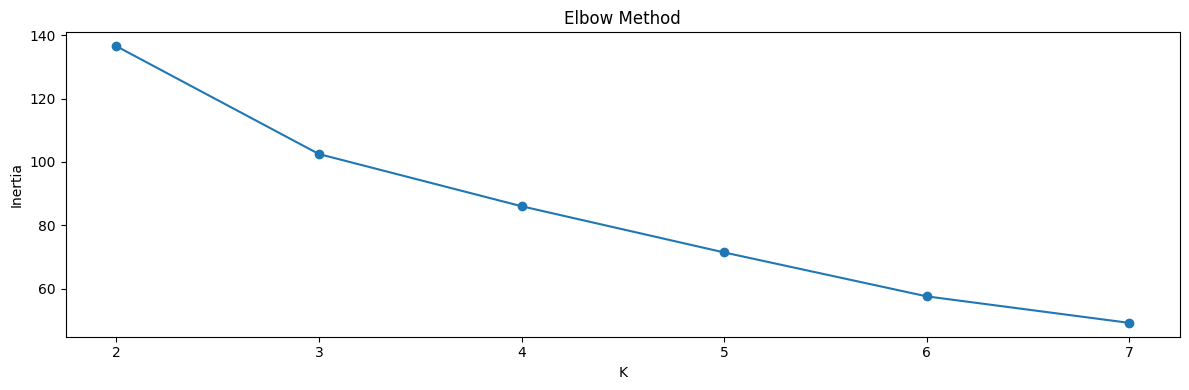

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 4))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

There isn't a super clear result of the elbow test here, but 3 clusters looks pretty good - so I'll run with it.

In [11]:
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
state_matrix['Cluster'] = km.fit_predict(X_scaled)

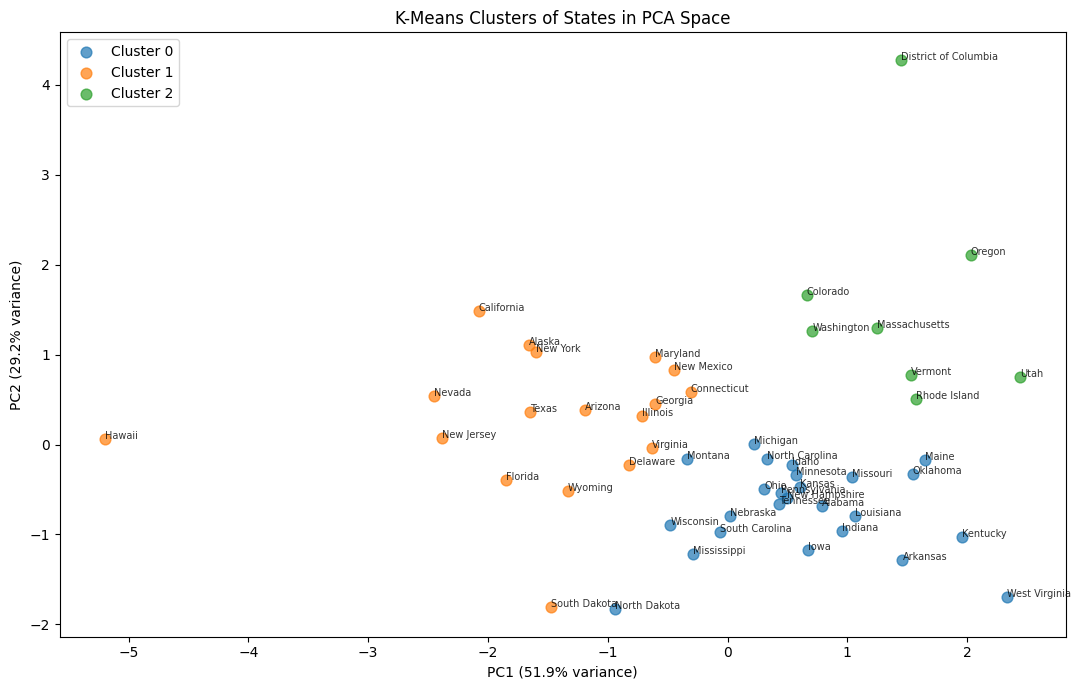

In [12]:
plt.figure(figsize=(11, 7))
for cluster in range(k):
    mask = state_matrix['Cluster'] == cluster
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {cluster}',
        alpha=0.7, s=60
    )

for i, state in enumerate(state_matrix.index):
    plt.annotate(state, (X_pca[i, 0], X_pca[i, 1]), fontsize=7, alpha=0.8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("K-Means Clusters of States in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
cluster_profile = state_matrix.groupby('Cluster').mean()
print(cluster_profile)

Indicator  Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks  \
Cluster                                                                    
0                                                  10.575996               
1                                                  10.329324               
2                                                  12.235303               

Indicator  Received Counseling or Therapy, Last 4 Weeks  \
Cluster                                                   
0                                              9.396004   
1                                              9.955729   
2                                             13.567045   

Indicator  Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks  \
Cluster                                                                                                         
0                                                  27.284970                                     

In [14]:
for cluster in range(k):
    states = state_matrix[state_matrix['Cluster'] == cluster].index.tolist()
    print(f"\nCluster {cluster}: {states}")


Cluster 0: ['Alabama', 'Arkansas', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'New Hampshire', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South Carolina', 'Tennessee', 'West Virginia', 'Wisconsin']

Cluster 1: ['Alaska', 'Arizona', 'California', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Illinois', 'Maryland', 'Nevada', 'New Jersey', 'New Mexico', 'New York', 'South Dakota', 'Texas', 'Virginia', 'Wyoming']

Cluster 2: ['Colorado', 'District of Columbia', 'Massachusetts', 'Oregon', 'Rhode Island', 'Utah', 'Vermont', 'Washington']


In [15]:
data = { # from wikipedia, 2025 not 2021
    "State": [
        "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado",
        "Connecticut", "Delaware", "District of Columbia", "Florida", "Georgia",
        "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa", "Kansas", "Kentucky",
        "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan", "Minnesota",
        "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
        "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota",
        "Ohio", "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island",
        "South Carolina", "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
        "Virginia", "Washington", "West Virginia", "Wisconsin", "Wyoming", "United States"
    ],
    "GDP_Per_Capita_2025_USD": [
        65694, 101742, 78463, 63703, 108012, 97184,
        102062, 110588, 277689, 78195, 81823,
        86967, 66784, 94503, 78188, 85570, 81075, 66617,
        73639, 72688, 90680, 114635, 72085, 91154,
        55877, 74710, 71947, 98153, 85752, 88688,
        92915, 71879, 123369, 79815, 102436,
        81239, 66554, 80225, 80895, 75329,
        68009, 86248, 80630, 91594, 89286, 75001,
        89914, 111860, 61873, 79199, 89379, 90004
    ]
}
 
gdp_df = pd.DataFrame(data)
print(f"\nShape: {gdp_df.shape}")

 


Shape: (52, 2)


In [16]:
for cluster in range(k):
    states = state_matrix[state_matrix['Cluster'] == cluster].index.tolist()
    n = len(states)
    tot = 0
    for state in range(n):
        tot += gdp_df.loc[gdp_df['State'] == states[state]]['GDP_Per_Capita_2025_USD'].values[0]
    
    print(f"\nCluster {cluster}: mean gdp_per_cap {tot / n:.2f}")


Cluster 0: mean gdp_per_cap 76288.88

Cluster 1: mean gdp_per_cap 92449.17

Cluster 2: mean gdp_per_cap 115151.12
